# Tumour Volume Comparison: Simulation vs Romano et al. (2021)

Compares simulated tumour volume trajectories (with clonal heterogeneity) against
the experimental data from Romano et al. and Tanaya's baseline model.

**Approach:** Load all trials per scenario, average across trials, convert cell counts
to tumour volume (% of brain), and align the x-axis so that radiation at timestep 200
maps to Day 12 post-implantation (matching Romano et al.).

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "HALModeling2024Outs"

# Volume conversion constants (Tanaya's report, page 30)
VOXEL_VOLUME_MM3 = 0.001       # 100um x 100um x 100um
RAT_BRAIN_VOLUME_MM3 = 2000    # Fischer rat brain
GRID_CELLS = 10000             # 100x100 grid

# Radiation is applied at timestep 200, mapped to Day 12 (Romano et al.)
RADIATION_TIMESTEP = 200
RADIATION_DAY = 12

def timestep_to_day(timestep):
    """Convert simulation timestep to biological day post-implantation."""
    return RADIATION_DAY + (timestep - RADIATION_TIMESTEP)

def cell_count_to_volume_pct(count):
    """Convert cell count to tumour volume as % of rat brain."""
    return (count * VOXEL_VOLUME_MM3 / RAT_BRAIN_VOLUME_MM3) * 100

print("Setup complete.")

Setup complete.


### Load all trials per scenario and compute mean + std

In [2]:
def load_all_trials(scenario, min_date="20260415"):
    """
    Load all CSV trials for a scenario, filtering out old runs.
    Only includes files with timestamp >= min_date to avoid mixing
    pre-bug-fix / pre-heterogeneity data.
    """
    folder = os.path.join(BASE_DIR, f"Scenario{scenario}")
    csv_files = sorted(glob.glob(os.path.join(folder, "TrialRunCounts_*.csv")))
    
    if not csv_files:
        print(f"  WARNING: No CSVs found for {scenario}")
        return []
    
    # Filter by date: filename format is TrialRunCounts_YYYYMMDD_HHMMSS.csv
    filtered = []
    skipped = 0
    for f in csv_files:
        basename = os.path.basename(f)
        # Extract date portion: TrialRunCounts_YYYYMMDD_...
        date_part = basename.split('_')[1]
        if date_part >= min_date:
            filtered.append(f)
        else:
            skipped += 1
    
    if skipped > 0:
        print(f"  {scenario}: skipped {skipped} old runs (before {min_date})")
    
    if not filtered:
        print(f"  WARNING: No CSVs for {scenario} after date filter")
        return []
    
    trials = [pd.read_csv(f) for f in filtered]
    print(f"  {scenario}: {len(trials)} trials, {len(trials[0])} timesteps each")
    return trials

def compute_mean_volume(trials):
    """
    Given a list of trial DataFrames, compute mean and std of tumour volume
    at each timestep. Returns (days, mean_vol, std_vol).
    """
    min_len = min(len(df) for df in trials)
    
    # Stack TumorCells across trials
    all_counts = np.array([df['TumorCells'].values[:min_len] for df in trials])
    
    # Convert to volume %
    all_volumes = cell_count_to_volume_pct(all_counts)
    
    mean_vol = np.mean(all_volumes, axis=0)
    std_vol = np.std(all_volumes, axis=0)
    
    timesteps = trials[0]['Timestep'].values[:min_len]
    days = timestep_to_day(timesteps)
    
    return days, mean_vol, std_vol

# Scenarios matching Romano et al. treatment groups
scenarios = ["Control", "BB5", "BB10", "BB15", "MRT200", "MRT400", "MRT600", "MB180", "MB350"]

print("Loading trials (filtering out pre-April 15 runs)...")
scenario_data = {}
for scen in scenarios:
    trials = load_all_trials(scen)
    if trials:
        days, mean_vol, std_vol = compute_mean_volume(trials)
        scenario_data[scen] = {
            'days': days,
            'mean': mean_vol,
            'std': std_vol,
            'n_trials': len(trials)
        }

print(f"\nLoaded {len(scenario_data)} scenarios.")

Loading trials (filtering out pre-April 15 runs)...
  Control: 10 trials, 541 timesteps each
  BB5: 10 trials, 541 timesteps each
  BB10: 10 trials, 541 timesteps each
  BB15: 10 trials, 541 timesteps each
  MRT200: 10 trials, 541 timesteps each
  MRT400: 10 trials, 541 timesteps each
  MRT600: 10 trials, 541 timesteps each
  MB180: 10 trials, 541 timesteps each
  MB350: 10 trials, 541 timesteps each

Loaded 9 scenarios.


### Main comparison plot — styled to match Romano et al. / Tanaya's figure

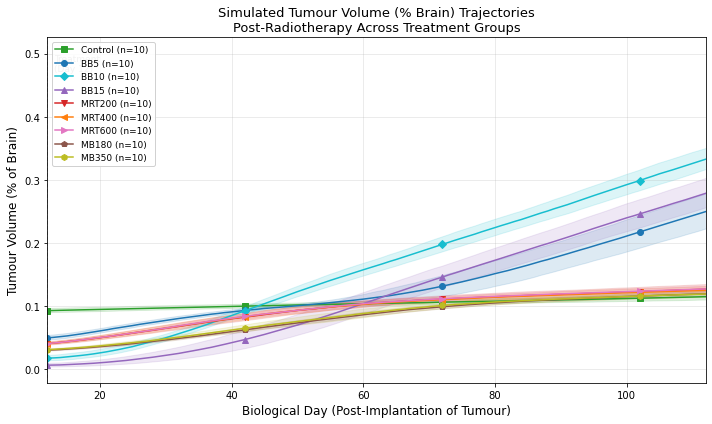

Saved to HALModeling2024Outs/tumour_volume_comparison.png


In [3]:
# Colour and style assignments to match Romano et al. figure conventions
scenario_style = {
    'Control':  {'color': '#2ca02c', 'marker': 's', 'label': 'Control'},
    'BB5':      {'color': '#1f77b4', 'marker': 'o', 'label': 'BB5'},
    'BB10':     {'color': '#17becf', 'marker': 'D', 'label': 'BB10'},
    'BB15':     {'color': '#9467bd', 'marker': '^', 'label': 'BB15'},
    'MRT200':   {'color': '#d62728', 'marker': 'v', 'label': 'MRT200'},
    'MRT400':   {'color': '#ff7f0e', 'marker': '<', 'label': 'MRT400'},
    'MRT600':   {'color': '#e377c2', 'marker': '>', 'label': 'MRT600'},
    'MB180':    {'color': '#8c564b', 'marker': 'p', 'label': 'MB180'},
    'MB350':    {'color': '#bcbd22', 'marker': 'h', 'label': 'MB350'},
}

fig, ax = plt.subplots(figsize=(10, 6))

for scen in scenarios:
    if scen not in scenario_data:
        continue
    d = scenario_data[scen]
    style = scenario_style[scen]
    
    # Only plot from Day 12 onward (post-treatment) to match Romano/Tanaya
    mask = d['days'] >= RADIATION_DAY
    days = d['days'][mask]
    mean = d['mean'][mask]
    std = d['std'][mask]
    
    # Subsample markers so the plot isn't cluttered (every 30 timesteps)
    marker_every = 30
    
    ax.plot(days, mean,
            color=style['color'],
            marker=style['marker'],
            markevery=marker_every,
            markersize=6,
            linewidth=1.5,
            label=f"{style['label']} (n={d['n_trials']})")
    
    # Shaded error band (mean +/- 1 std)
    ax.fill_between(days, mean - std, mean + std,
                    color=style['color'], alpha=0.15)

# Mark treatment day
ax.axvline(x=RADIATION_DAY, color='grey', linestyle='--', alpha=0.5, linewidth=1)
ax.text(RADIATION_DAY + 1, ax.get_ylim()[1] * 0.95, 'Treatment\n(Day 12)',
        fontsize=9, color='grey', va='top')

ax.set_xlabel('Biological Day (Post-Implantation of Tumour)', fontsize=12)
ax.set_ylabel('Tumour Volume (% of Brain)', fontsize=12)
ax.set_title('Simulated Tumour Volume (% Brain) Trajectories\n'
             'Post-Radiotherapy Across Treatment Groups', fontsize=13)
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(RADIATION_DAY, 112)

plt.tight_layout()
plt.savefig('HALModeling2024Outs/tumour_volume_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved to HALModeling2024Outs/tumour_volume_comparison.png")

### Summary table: final tumour volume per scenario

In [4]:
# Summary table: volume at key timepoints and at end of simulation
print(f"{'Scenario':<12} {'Trials':>6} {'Vol at Day 42':>15} {'Vol at Day 72':>15} {'Final Vol':>15} {'Final Day':>10}")
print("-" * 75)

for scen in scenarios:
    if scen not in scenario_data:
        continue
    d = scenario_data[scen]
    
    # Find index for specific days
    day42_idx = np.argmin(np.abs(d['days'] - 42))
    day72_idx = np.argmin(np.abs(d['days'] - 72))
    
    vol42 = f"{d['mean'][day42_idx]:.4f}%"
    vol72 = f"{d['mean'][day72_idx]:.4f}%"
    vol_final = f"{d['mean'][-1]:.4f}%"
    final_day = f"{d['days'][-1]}"
    
    print(f"{scen:<12} {d['n_trials']:>6} {vol42:>15} {vol72:>15} {vol_final:>15} {final_day:>10}")

Scenario     Trials   Vol at Day 42   Vol at Day 72       Final Vol  Final Day
---------------------------------------------------------------------------
Control          10         0.1002%         0.1066%         0.3333%        352
BB5              10         0.0934%         0.1318%         0.4996%        352
BB10             10         0.0929%         0.1979%         0.5000%        352
BB15             10         0.0473%         0.1462%         0.5000%        352
MRT200           10         0.0828%         0.1114%         0.4576%        352
MRT400           10         0.0835%         0.1105%         0.4554%        352
MRT600           10         0.0840%         0.1119%         0.4572%        352
MB180            10         0.0627%         0.0993%         0.4754%        352
MB350            10         0.0652%         0.1013%         0.4816%        352


### Relative growth: normalised to volume at treatment day

This shows how much the tumour grew or shrank *relative to the treatment day*, 
making it easier to compare treatment effectiveness across scenarios regardless 
of the absolute volume scale.

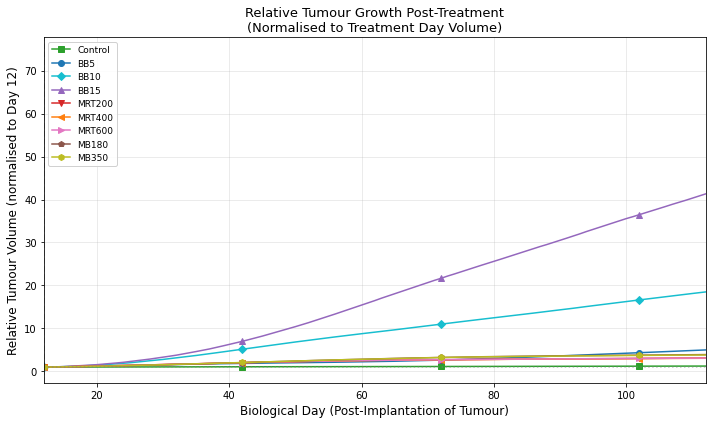

Saved to HALModeling2024Outs/tumour_volume_relative.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

for scen in scenarios:
    if scen not in scenario_data:
        continue
    d = scenario_data[scen]
    style = scenario_style[scen]
    
    mask = d['days'] >= RADIATION_DAY
    days = d['days'][mask]
    mean = d['mean'][mask]
    
    # Normalise to volume at treatment day
    vol_at_treatment = mean[0] if mean[0] > 0 else 1e-9
    normalised = mean / vol_at_treatment
    
    ax.plot(days, normalised,
            color=style['color'],
            marker=style['marker'],
            markevery=30,
            markersize=6,
            linewidth=1.5,
            label=style['label'])

ax.axhline(y=1.0, color='grey', linestyle=':', alpha=0.5)
ax.axvline(x=RADIATION_DAY, color='grey', linestyle='--', alpha=0.5)

ax.set_xlabel('Biological Day (Post-Implantation of Tumour)', fontsize=12)
ax.set_ylabel('Relative Tumour Volume (normalised to Day 12)', fontsize=12)
ax.set_title('Relative Tumour Growth Post-Treatment\n(Normalised to Treatment Day Volume)', fontsize=13)
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(RADIATION_DAY, 112)

plt.tight_layout()
plt.savefig('HALModeling2024Outs/tumour_volume_relative.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved to HALModeling2024Outs/tumour_volume_relative.png")